# 1. Motivation and Goal


link to the dataset from Kaggle: https://www.kaggle.com/datasets/shahriarkabir/drug-discovery-virtual-screening-dataset

# 2. Import libraries and setup

In [10]:
import os

import pandas as pd

# 3. Data importing and Data ingestion

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shahriarkabir/drug-discovery-virtual-screening-dataset")

print("Path to dataset files:", path)

In [5]:
os.listdir(path)

['drug_discovery_virtual_screening.csv']

In [43]:
# Load the dataset
df = pd.read_csv(os.path.join(path, "drug_discovery_virtual_screening.csv"))

In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   compound_id          2000 non-null   str    
 1   protein_id           2000 non-null   str    
 2   molecular_weight     2000 non-null   float64
 3   logp                 1940 non-null   float64
 4   h_bond_donors        2000 non-null   int64  
 5   h_bond_acceptors     2000 non-null   int64  
 6   rotatable_bonds      2000 non-null   int64  
 7   polar_surface_area   1940 non-null   float64
 8   compound_clogp       2000 non-null   float64
 9   protein_length       2000 non-null   int64  
 10  protein_pi           2000 non-null   float64
 11  hydrophobicity       1940 non-null   float64
 12  binding_site_size    2000 non-null   float64
 13  mw_ratio             2000 non-null   float64
 14  logp_pi_interaction  2000 non-null   float64
 15  binding_affinity     2000 non-null   float64
 16 

In [46]:
df.describe()

,molecular_weight,logp,h_bond_donors,h_bond_acceptors,rotatable_bonds,polar_surface_area,compound_clogp,protein_length,protein_pi,hydrophobicity,binding_site_size,mw_ratio,logp_pi_interaction,binding_affinity,active
count,2000.000000,1940.000000,2000.000000,2000.000000,2000.00000,1940.000000,2000.000000,2000.00000,2000.000000,1940.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,456.772168,3.479480,1.961000,5.115000,5.96850,80.026470,2.813403,848.92600,6.460332,0.645325,15.155982,0.708989,22.598329,6.531228,0.304000
std,104.874658,1.638638,1.348105,2.330985,2.40778,25.344944,1.188590,380.83777,1.210236,0.095419,2.997837,0.475588,10.918200,1.194584,0.460098
min,50.307070,-4.325172,0.000000,0.000000,0.00000,-24.653688,-1.426170,201.00000,2.597565,0.332013,4.655871,0.097804,-6.624581,1.990381,0.000000
25%,388.747480,2.419505,1.000000,3.000000,4.00000,63.166240,2.006000,509.50000,5.615083,0.577986,13.144847,0.383770,14.826016,5.856086,0.000000
50%,454.869085,3.501416,2.000000,5.000000,6.00000,80.606617,2.773587,844.00000,6.473527,0.647452,15.237835,0.532021,21.858904,6.480304,0.000000
75%,520.982885,4.518801,3.000000,7.000000,7.00000,97.366501,3.620260,1192.00000,7.270822,0.711428,17.184475,0.867184,29.526168,7.164685,1.000000
max,994.048532,9.978489,8.000000,15.000000,17.00000,159.627362,6.891681,1499.00000,10.266937,0.978030,24.887713,3.403706,76.998672,15.039709,1.000000


In [63]:
df.head()

,compound_id,protein_id,molecular_weight,logp,h_bond_donors,h_bond_acceptors,rotatable_bonds,polar_surface_area,compound_clogp,protein_length,protein_pi,hydrophobicity,binding_site_size,mw_ratio,logp_pi_interaction,binding_affinity,active
0,CID_00000,PID_361,499.671415,2.487233,1,7,4,113.350817,4.050696,678,6.019657,0.812534,12.512165,0.736978,14.972288,5.996665,0
1,CID_00001,PID_165,436.173570,3.283222,3,4,4,71.981132,3.704408,876,6.447408,0.651417,11.538420,0.497915,21.168271,6.445742,0
2,CID_00002,PID_168,514.768854,NaN,2,11,11,83.936307,1.869610,658,3.925837,0.633467,13.155702,0.782323,9.074061,5.689583,0
3,CID_00003,PID_226,602.302986,3.038058,0,5,5,79.868125,2.451909,312,7.597056,0.513038,12.071822,1.930458,23.080293,6.043438,0
4,CID_00004,PID_224,426.584663,0.659578,2,4,5,88.198676,1.771936,1418,4.249454,0.613571,15.850448,0.300835,2.802846,4.845055,0


# 4. Data cleaning and Preprocessing

### 4.1 Handling missing values

In [71]:
# Check for missing values
df.isna().sum()


# Print columns with missing values
for col in df.columns:
    if df[col].isna().sum() > 0:
        print(f"Column '{col}' has {df[col].isna().sum()} missing values.")


# print row with missing values
missing_rows = df[df.isna().any(axis=1)] # get rows with missing values
missing_rows




Column 'logp' has 60 missing values.
Column 'polar_surface_area' has 60 missing values.
Column 'hydrophobicity' has 60 missing values.


,compound_id,protein_id,molecular_weight,logp,h_bond_donors,h_bond_acceptors,rotatable_bonds,polar_surface_area,compound_clogp,protein_length,protein_pi,hydrophobicity,binding_site_size,mw_ratio,logp_pi_interaction,binding_affinity,active
2,CID_00002,PID_168,514.768854,NaN,2,11,11,83.936307,1.869610,658,3.925837,0.633467,13.155702,0.782323,9.074061,6.531228,0
5,CID_00005,PID_201,426.586304,3.819941,2,1,5,77.316388,2.111839,1243,4.613013,NaN,18.652637,0.343191,17.621434,6.531228,0
12,CID_00012,PID_495,474.196227,2.346286,1,6,8,105.440162,2.921681,602,7.020256,NaN,18.400130,0.787701,16.471533,6.531228,0
15,CID_00015,PID_214,393.771247,NaN,1,4,6,77.593871,3.890246,861,6.336960,0.885945,17.155356,0.457342,20.336957,6.531228,0
26,CID_00026,PID_108,334.900642,6.200767,4,7,6,NaN,2.251235,211,8.094394,0.688016,13.784544,1.587207,50.191447,6.531228,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1940,CID_01940,PID_324,480.805054,4.068730,2,5,6,68.608255,4.342588,235,6.071302,NaN,12.295430,2.045979,24.702485,6.531228,1
1950,CID_01950,PID_391,272.696753,4.272941,2,9,7,95.739166,2.290464,815,6.062352,NaN,15.540084,0.334597,25.904076,6.531228,1
1952,CID_01952,PID_320,359.426770,6.776145,1,7,5,NaN,2.996687,523,9.457642,0.578623,14.452281,0.687240,64.086357,6.531228,1
1988,CID_01988,PID_319,385.851840,6.385169,4,9,8,NaN,3.539357,482,5.766423,0.607747,14.100861,0.800522,36.819582,6.531228,1


There are in total 174 rows with missing values: drop or replace with the everage of the column. 

In [72]:


print(f"There are {len(df)} rows in the dataset. \n Which makes {len(missing_rows)/len(df)*100}%")

There are 2000 rows in the dataset. 
 Which makes 8.7%


In [75]:
# replace missing values with mean of the column

df.fillna(df.mean(numeric_only=True), inplace= True)


,compound_id,protein_id,molecular_weight,logp,h_bond_donors,h_bond_acceptors,rotatable_bonds,polar_surface_area,compound_clogp,protein_length,protein_pi,hydrophobicity,binding_site_size,mw_ratio,logp_pi_interaction,binding_affinity,active
0,CID_00000,PID_361,499.671415,2.487233,1,7,4,113.350817,4.050696,678,6.019657,0.812534,12.512165,0.736978,14.972288,5.996665,0
1,CID_00001,PID_165,436.173570,3.283222,3,4,4,71.981132,3.704408,876,6.447408,0.651417,11.538420,0.497915,21.168271,6.445742,0
2,CID_00002,PID_168,514.768854,3.479480,2,11,11,83.936307,1.869610,658,3.925837,0.633467,13.155702,0.782323,9.074061,6.531228,0
3,CID_00003,PID_226,602.302986,3.038058,0,5,5,79.868125,2.451909,312,7.597056,0.513038,12.071822,1.930458,23.080293,6.043438,0
4,CID_00004,PID_224,426.584663,0.659578,2,4,5,88.198676,1.771936,1418,4.249454,0.613571,15.850448,0.300835,2.802846,4.845055,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,CID_01995,PID_425,557.015024,3.542686,4,5,11,102.329688,1.470121,240,7.862185,0.770925,21.308909,2.320896,27.853256,7.209850,1
1996,CID_01996,PID_100,447.347874,0.383282,1,8,5,52.321214,3.739447,718,7.401501,0.644721,16.578658,0.623047,2.836864,9.029696,1
1997,CID_01997,PID_265,361.812535,3.019553,0,4,9,86.722469,3.122027,1228,5.551238,0.717044,16.829751,0.294636,16.762259,5.728118,0
1998,CID_01998,PID_125,433.693304,5.965067,0,4,10,86.932238,3.866579,1244,5.680128,0.661245,10.604194,0.348628,33.882348,7.324152,1


In [78]:
df.dtypes

compound_id                str
protein_id                 str
molecular_weight       float64
logp                   float64
h_bond_donors            int64
h_bond_acceptors         int64
rotatable_bonds          int64
polar_surface_area     float64
compound_clogp         float64
protein_length           int64
protein_pi             float64
hydrophobicity         float64
binding_site_size      float64
mw_ratio               float64
logp_pi_interaction    float64
binding_affinity       float64
active                   int64
dtype: object

### 4.2 Handling outliers

In [86]:

# Filter numeric columns and handle outliers

# get the statistics of outliers in each column
for col in df.select_dtypes(include=["int64", "float64"]).columns:
    if col != "active":
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        print(f"Column: {col}, Outliers: {len(outliers)}")

Column: molecular_weight, Outliers: 34
Column: logp, Outliers: 37
Column: h_bond_donors, Outliers: 4
Column: h_bond_acceptors, Outliers: 3
Column: rotatable_bonds, Outliers: 46
Column: polar_surface_area, Outliers: 14
Column: compound_clogp, Outliers: 15
Column: protein_length, Outliers: 0
Column: protein_pi, Outliers: 10
Column: hydrophobicity, Outliers: 12
Column: binding_site_size, Outliers: 14
Column: mw_ratio, Outliers: 144
Column: logp_pi_interaction, Outliers: 17
Column: binding_affinity, Outliers: 69


For now I will just leave the outliers, they might still carry important insights for the data. 

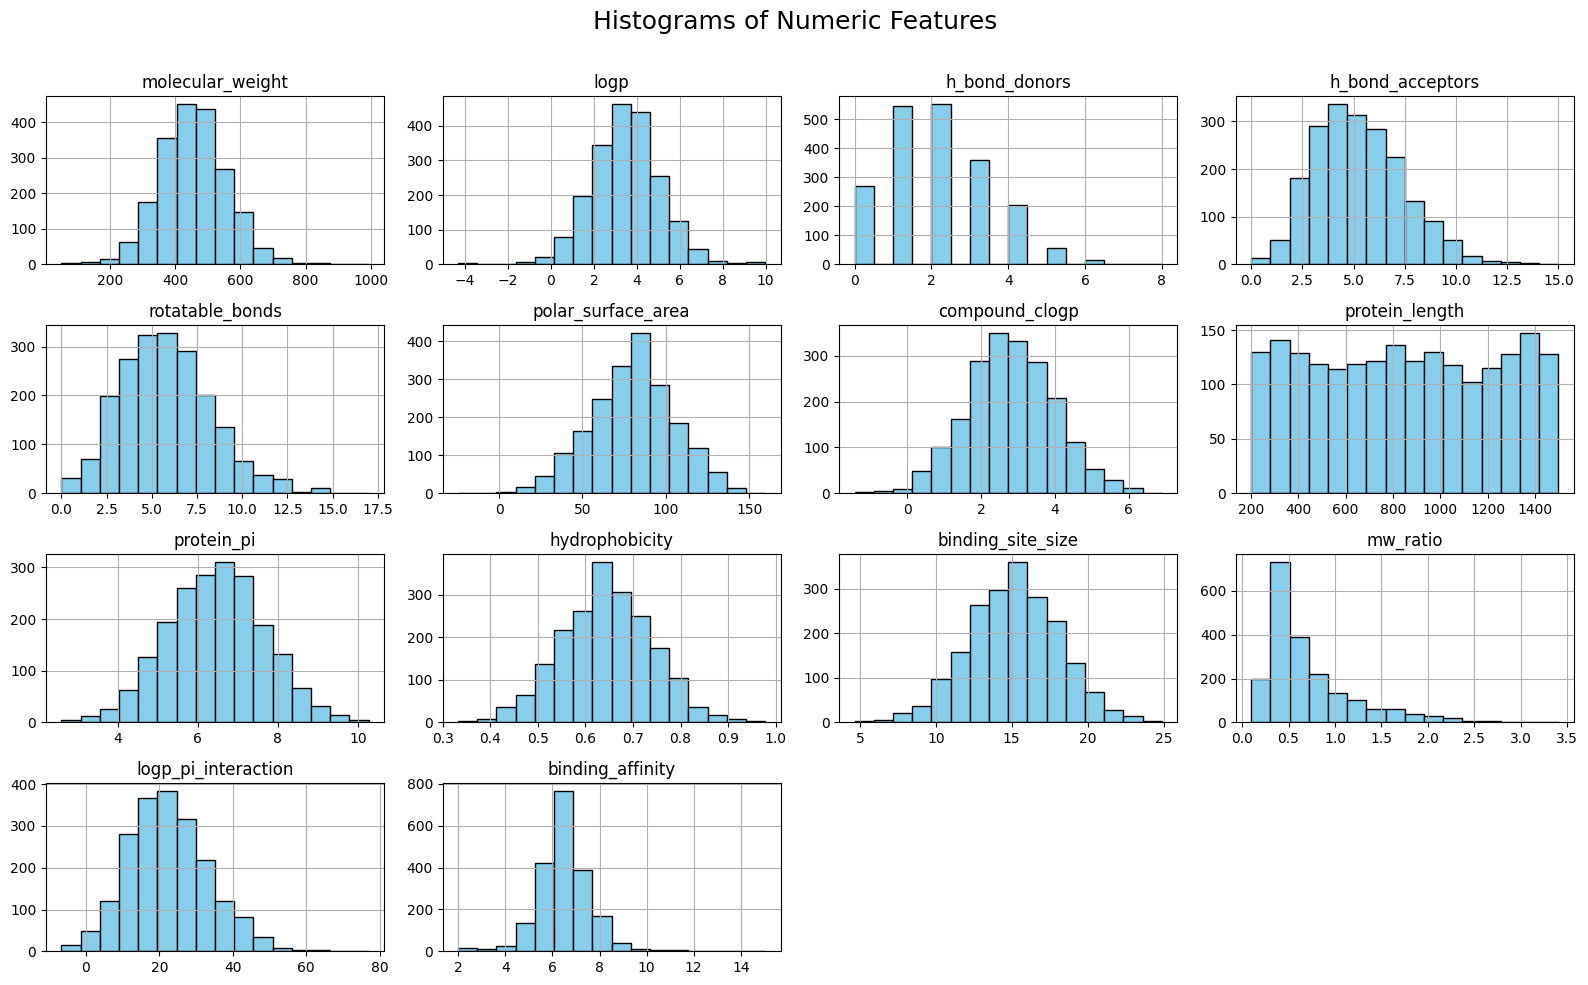

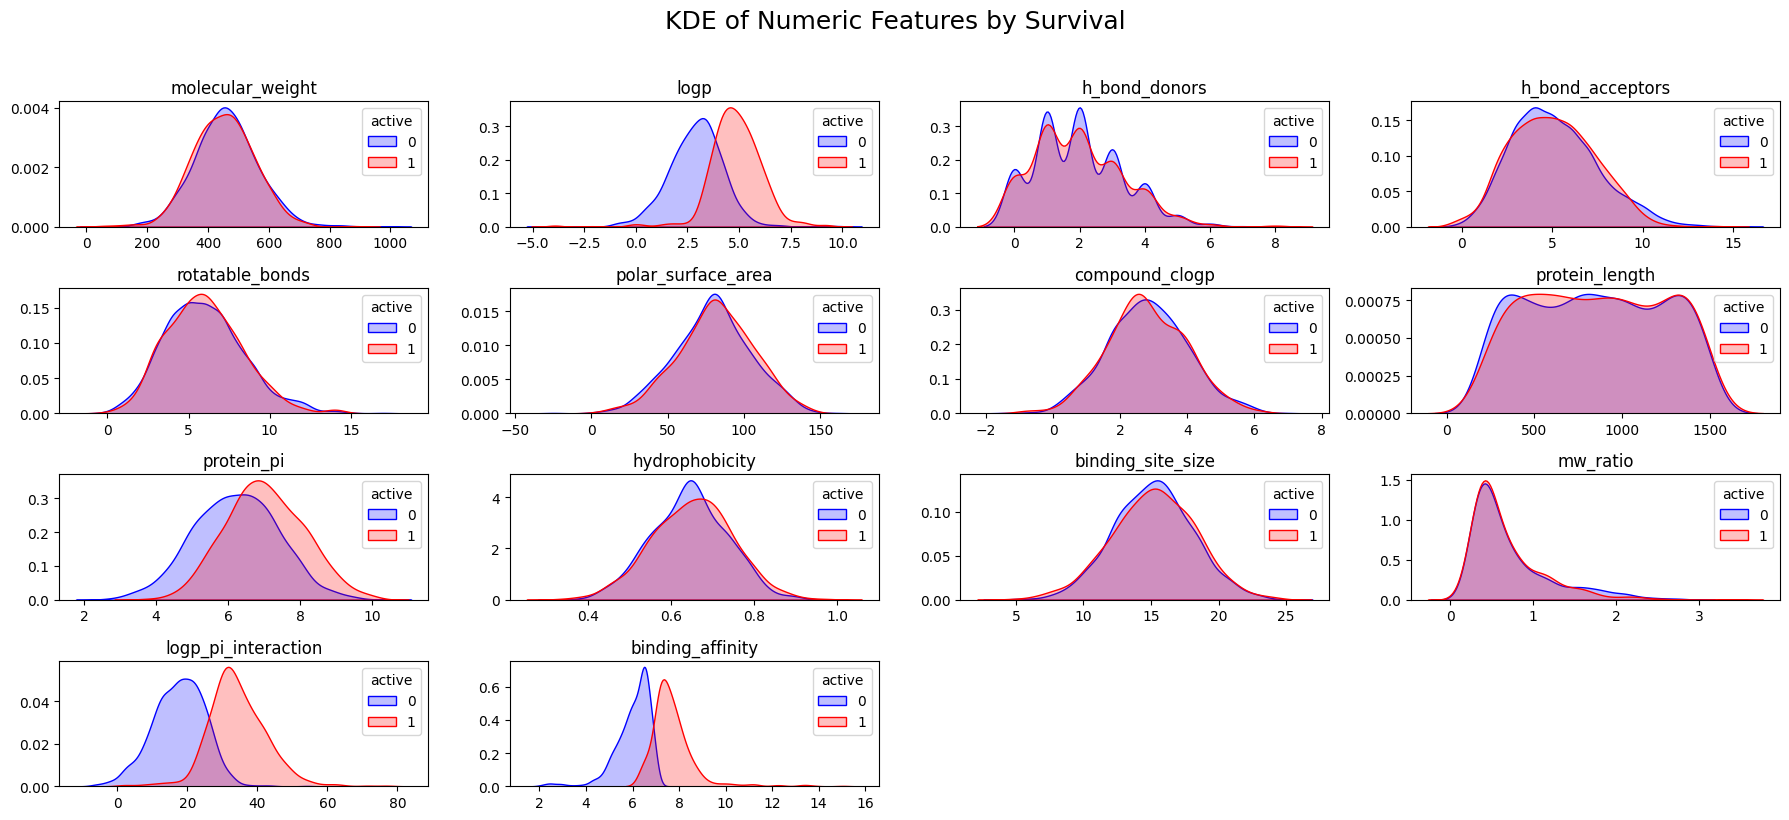

In [108]:
# Histograms for all numerics
import math
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.drop("active")

df[numeric_cols].hist(bins=16, figsize=(16, 10), layout=(4, 4), color='skyblue', edgecolor='black')
plt.suptitle("Histograms of Numeric Features", fontsize=18)
plt.tight_layout(rect=[0,0,1,0.97])
plt.show()

# KDE by target
fig, axes = plt.subplots(math.ceil(len(numeric_cols)/4), 4, figsize=(18, 8))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    [sns.kdeplot(df[df['active']==event][col], fill=True, ax=ax, label=event, color=c)
     for event, c in zip([0,1], ['blue','red'])]
    ax.set_title(col)
    ax.legend(title='active')
    ax.set_xlabel("")
    ax.set_ylabel("")

[ax.axis('off') for ax in axes[len(numeric_cols):]]  # Hide unused axes

fig.suptitle("KDE of Numeric Features by Survival", y=1.02, fontsize=18)
plt.tight_layout()
plt.show()

Histograms: most of the features seems to be normally distributed
KDE plots: features are normally distrbuted for both labels of the target values. Interesting to see, that peaks for the logp_pi_interaction, binding_affinity and logp are different for the target values. 

# 5. Exploratory data analysis

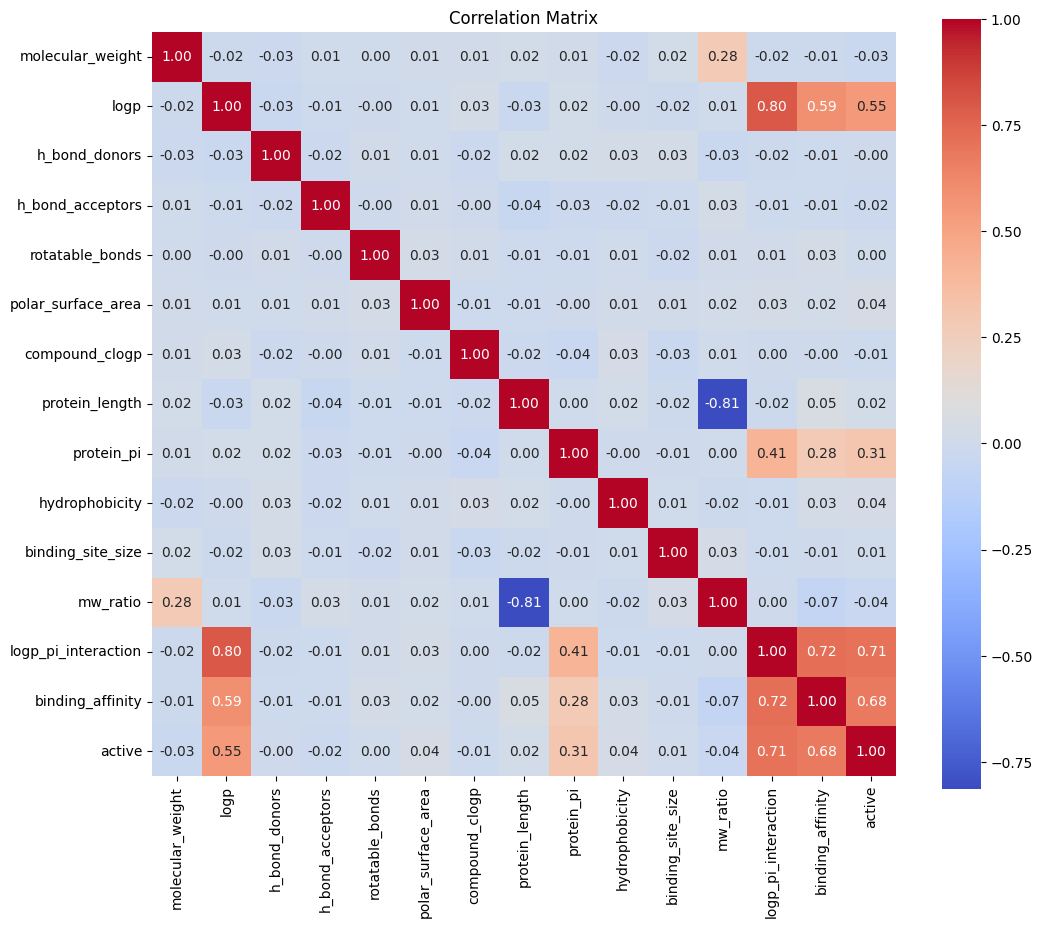

In [94]:
# correlation matrix

# Compute the correlation matrix
corr = df.select_dtypes(include=("int64","float64")).corr()


# Set up the matplotlib figure
plt.figure(figsize=(12, 10))


# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix")
plt.show()

Correlation analysis shows there is a strong correlation among several numeric features. The target feature correlates well with t he binding affinity, logp_pi_interaction, logp - which biologically makes sense. If a protein has a strong binding affinity, then there is a higher chance that it has an activity on its receptor/another binding protein partner. 


In [95]:
corr

,molecular_weight,logp,h_bond_donors,h_bond_acceptors,rotatable_bonds,polar_surface_area,compound_clogp,protein_length,protein_pi,hydrophobicity,binding_site_size,mw_ratio,logp_pi_interaction,binding_affinity,active
molecular_weight,1.000000,-0.019989,-0.025079,0.005201,0.002362,0.014202,0.010893,0.019418,0.012978,-0.021763,0.020076,0.279778,-0.015833,-0.014640,-0.034495
logp,-0.019989,1.000000,-0.032202,-0.010988,-0.003249,0.006816,0.026707,-0.034123,0.017885,-0.003258,-0.017030,0.006265,0.796935,0.590754,0.546438
h_bond_donors,-0.025079,-0.032202,1.000000,-0.023725,0.010718,0.005642,-0.023130,0.020060,0.021960,0.026339,0.026697,-0.033148,-0.015958,-0.006245,-0.001845
h_bond_acceptors,0.005201,-0.010988,-0.023725,1.000000,-0.004702,0.009819,-0.001364,-0.043877,-0.025392,-0.023289,-0.009298,0.028244,-0.011533,-0.006299,-0.021419
rotatable_bonds,0.002362,-0.003249,0.010718,-0.004702,1.000000,0.025339,0.011808,-0.009324,-0.008125,0.005195,-0.023217,0.008329,0.010625,0.026042,0.003230
polar_surface_area,0.014202,0.006816,0.005642,0.009819,0.025339,1.000000,-0.007137,-0.010048,-0.000838,0.014367,0.014204,0.021897,0.025089,0.016615,0.040911
compound_clogp,0.010893,0.026707,-0.023130,-0.001364,0.011808,-0.007137,1.000000,-0.023772,-0.041250,0.031446,-0.028225,0.005167,0.000601,-0.003574,-0.011237
protein_length,0.019418,-0.034123,0.020060,-0.043877,-0.009324,-0.010048,-0.023772,1.000000,0.003158,0.015897,-0.018603,-0.814064,-0.018039,0.053533,0.017372
protein_pi,0.012978,0.017885,0.021960,-0.025392,-0.008125,-0.000838,-0.041250,0.003158,1.000000,-0.000551,-0.006212,0.002234,0.412493,0.283878,0.307753
hydrophobicity,-0.021763,-0.003258,0.026339,-0.023289,0.005195,0.014367,0.031446,0.015897,-0.000551,1.000000,0.005487,-0.015538,-0.012727,0.027294,0.035528


# 6. Machine Learning Modeling

# 7. Explainable AI (XAI)

# 8. Conclusion